In [48]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings, HuggingFaceEndpointEmbeddings
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from typing import List
from langchain_core.documents import Document
from langchain_tavily import TavilySearch
from dotenv import load_dotenv
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers.ensemble import EnsembleRetriever
import os
from langgraph.graph import StateGraph, START, END
import nltk
from langchain_cohere import CohereEmbeddings
from typing import TypedDict, Literal

In [37]:
load_dotenv()

True

In [18]:

docs = [
    PyPDFLoader('Documents/Company_Policies.pdf').load() + 
    PyPDFLoader('Documents/Company_Profile.pdf').load() + 
    PyPDFLoader('Documents/Product_and_Pricing.pdf').load()  
]


In [19]:
docs = docs[0]

In [11]:
!pip install langchain-cohere


[notice] A new release of pip is available: 23.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip



     ---------------------------------------- 0.0/45.1 kB ? eta -:--:--
     ----------------- -------------------- 20.5/45.1 kB 320.0 kB/s eta 0:00:01
     ----------------- -------------------- 20.5/45.1 kB 320.0 kB/s eta 0:00:01
     ----------------- -------------------- 20.5/45.1 kB 320.0 kB/s eta 0:00:01
     ----------------- -------------------- 20.5/45.1 kB 320.0 kB/s eta 0:00:01
     ----------------- -------------------- 20.5/45.1 kB 320.0 kB/s eta 0:00:01
     ---------------------------------- --- 41.0/45.1 kB 130.7 kB/s eta 0:00:01
     ---------------------------------- --- 41.0/45.1 kB 130.7 kB/s eta 0:00:01
     -------------------------------------- 45.1/45.1 kB 106.0 kB/s eta 0:00:00
     ---------------------------------------- 0.0/334.3 kB ? eta -:--:--
     - -------------------------------------- 10.2/334.3 kB ? eta -:--:--
     --- --------------------------------- 30.7/334.3 kB 660.6 kB/s eta 0:00:01
     ---- -------------------------------- 41.0/334.3 kB 393

In [ ]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150)

chunks = splitter.split_documents(docs)

In [21]:
embedding_model = CohereEmbeddings(
model="embed-english-v3.0"
)

In [ ]:
# vector = embedding_model.embed_query('Hello World')

# print(vector)

[-0.03955078, -0.04449463, -0.08935547, -0.083618164, -0.009277344, -0.009468079, -0.048187256, 0.07165527, 0.011749268, 0.015777588, -0.028137207, 0.03479004, 0.037475586, -0.04272461, 0.051696777, -0.027877808, 0.04736328, 0.01612854, 0.0038070679, -0.005092621, -0.011886597, 0.023468018, -0.00010693073, 0.021331787, 0.049194336, -0.023544312, 0.01828003, 0.0063476562, -0.047790527, -0.042541504, 0.0024280548, 0.04647827, 0.014518738, 0.02230835, 0.0005083084, 0.04827881, -0.024429321, 0.0061416626, 0.008453369, 0.003993988, 0.015342712, -0.008094788, 0.017105103, -0.029220581, -0.023956299, 0.010017395, -0.043792725, -0.025390625, 0.03253174, -0.030670166, 0.005630493, -0.020050049, -0.0033817291, -0.007785797, -0.009498596, 0.003932953, -0.06072998, -0.018722534, 0.009635925, 0.08441162, 0.03729248, 0.0028190613, 0.005130768, -0.005970001, 0.016525269, -0.0030670166, 0.016281128, 0.012077332, 0.023391724, 0.025375366, 0.004802704, 0.012832642, -0.017684937, -0.023895264, -0.0122528

In [22]:
vector_store = Chroma.from_documents(
    embedding=embedding_model,
    documents=chunks,
    persist_directory='self-rag-db/chroma-srag.db'
)

In [ ]:
# retriever = vector_store.as_retriever(search_kwargs={
#     'k': 4
# })

# docs = retriever.invoke('What is the componys policy?')

# for d in docs:
#     print(d.page_content)


In [59]:
vector_retriever = vector_store.as_retriever(search_type = 'similarity', search_kwargs = {
    'k': 4
})

In [60]:
_store_data = vector_store.get(include=["documents", "metadatas"])
_all_chunks_for_bm25 = [
    Document(page_content=content, metadata=meta or {})
    for content, meta in zip(_store_data["documents"], _store_data["metadatas"])
]

bm25_retriever = BM25Retriever.from_documents(_all_chunks_for_bm25)
bm25_retriever.k = 4

retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, vector_retriever],
    weights=[0.4, 0.6]
)

In [61]:
class Should_Retriever(BaseModel):
    should_retrieve: bool  = Field(..., description= "True if external documents are needed to answer reliably, else False.")

In [62]:
groq_llm = ChatGroq(
    model = 'llama-3.3-70b-versatile',
    api_key = os.getenv('GROQ_API_KEY')
)

In [63]:
decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

should_retrieve_llm = decide_retrieval_prompt | groq_llm.with_structured_output(Should_Retriever)


In [103]:
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]

    relevant_docs: List[Document]

    answer: str

    retries: int

    context: str    

    issup: Literal["fully_supported", "partially_supported", "no_support"]

    evidence: List[str]

    isuse: Literal["useful", "not_useful"]
    use_reason: str

    retrieval_query: str
    rewrite_tries: int

In [65]:
def should_retriever_node(state: State):
    question = state['question']

    need_retrieval = should_retrieve_llm.invoke(
        {
            'question': question
        }
    )

    return {
        'need_retrieval': need_retrieval.should_retrieve
    }

In [66]:
gpt_llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

In [67]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

generate_response_chain = direct_generation_prompt | gpt_llm

In [68]:


def generate_direct(state: State):
    out = generate_response_chain.invoke(
        {
            'question': state['question']
        }
    )
    return {
        "answer": out.content
    }

In [69]:
def retrieve_node(state: State):
    return {
        'docs': retriever.invoke(state['question'])
    }

In [70]:
def route_after_decide(state: State) -> Literal['generate_direct', 'retrieve']:

    if state['need_retrieval']:
        return 'retrieve'

    return 'generate_direct'

In [74]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevance_llm = gpt_llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    
    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}

In [ ]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

rag_generation_chain = rag_generation_prompt | gpt_llm

In [85]:
def generate_from_context(state: State):
    # Stuff relevant docs into one block
    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs", [])]
    ).strip()

    if not context:
        return {"answer": "No relevant document found.", "context": ""}

    out = rag_generation_chain.invoke(
        {
            'question': state['question'],
            'context': context
        }
    )
    return {"answer": out.content, "context": context}

def no_answer_found(state: State):
    return {"answer": "No answer found.", "context": ""}

In [80]:

def no_relevant_docs(state: State):
    return {"answer": "No relevant document found.", "context": ""}


In [78]:

def route_after_relevance(state: State) -> Literal["generate_from_context", "no_relevant_docs"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "no_relevant_docs"

In [82]:
class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)



issup_chain = issup_prompt | gpt_llm.with_structured_output(IsSUPDecision)


In [83]:
def is_sup(state: State):
    decision: IsSUPDecision = issup_chain.invoke({
        'question' : state["question"],
        'answer' : state.get("answer", ""),
        'context': state.get("context", "")
    }        
    )
    
    return {"issup": decision.issup, "evidence": decision.evidence}

In [86]:
MAX_RETRIES = 10

In [92]:
def route_after_issup(state: State) -> Literal["accept_answer", "revise_answer"]:
    # accept if fully supported
    if state.get("issup") == "fully_supported":
        return "accept_answer"

    # stop if we've already tried enough
    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"   # or return a "give_up" node if you want

    # otherwise revise again
    return "revise_answer"

In [108]:
# def accept_answer(state: State):
#     return {}  # keep answer as-is

In [89]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)


revise_answer_chain = revise_prompt | groq_llm

In [90]:
def revise_answer(state: State):
    out = revise_answer_chain.invoke({
            'question' : state["question"],
            'answer' : state.get("answer", ""),
            'context' : state.get("context", "")
        }
    )

    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,  # increment
    }

In [99]:
class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(..., description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

isuse_llm_chain = isuse_prompt | groq_llm.with_structured_output(IsUSEDecision)

In [ ]:
MAX_REWRITE_TRIES = 3

In [100]:
def is_use(state: State):
    decision: IsUSEDecision = isuse_llm_chain.invoke({
            'question' : state["question"],
            'answer' : state.get("answer", ""),
    }
    )
    return {"isuse": decision.isuse, "use_reason": decision.reason}

In [102]:
class RewriteDecision(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )

rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)



rewrite_llm_chain = rewrite_for_retrieval_prompt | groq_llm.with_structured_output(RewriteDecision)

In [104]:
def rewrite_question(state: State):
    decision: RewriteDecision = rewrite_llm_chain.invoke({
            'question' : state["question"],
            'retrieval_query' : state.get("retrieval_query", ""),
            'answer' : state.get("answer", ""),
    }
    )

    return {
        "retrieval_query": decision.retrieval_query,
        "rewrite_tries": state.get("rewrite_tries", 0) + 1,
        # optional: reset these so next pass is clean
        "docs": [],
        "relevant_docs": [],
        "context": "",
    }

In [105]:
def route_after_isuse(state: State) -> Literal["END", "rewrite_question", "no_answer_found"]:
    if state.get("isuse") == "useful":
        return "END"

    if state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
        return "no_answer_found"

    return "rewrite_question"

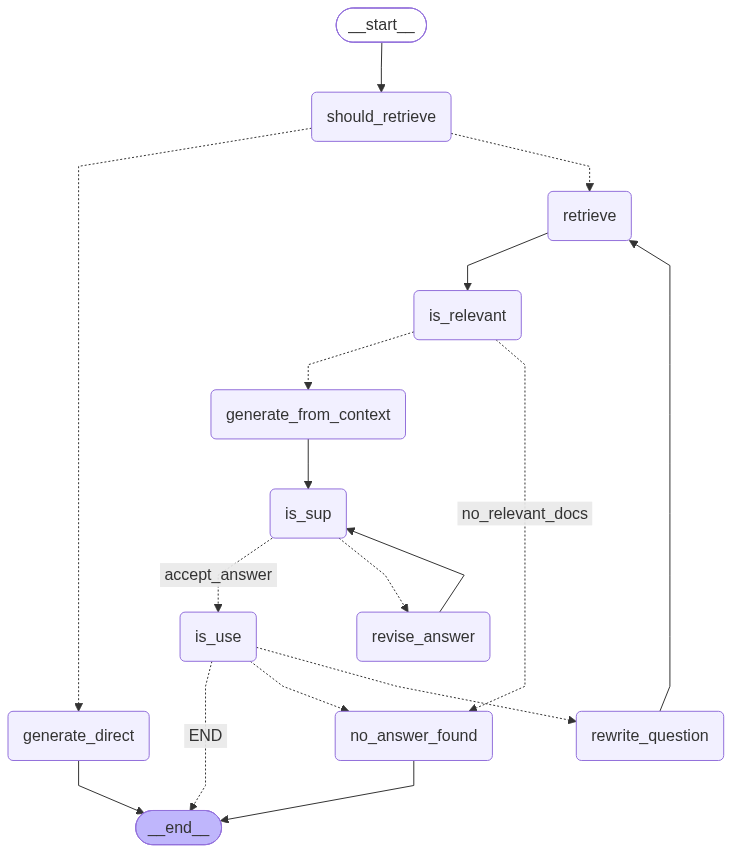

In [109]:
g = StateGraph(State)

g.add_node('should_retrieve', should_retriever_node)
g.add_node('generate_direct', generate_direct)
g.add_node('retrieve', retrieve_node)
g.add_node('is_relevant', is_relevant)
g.add_node('generate_from_context', generate_from_context)
g.add_node('no_answer_found', no_answer_found)
g.add_node('is_sup', is_sup)
g.add_node('revise_answer', revise_answer)
g.add_node("is_use", is_use)
g.add_node("rewrite_question", rewrite_question)


g.add_edge(START, 'should_retrieve')

g.add_conditional_edges('should_retrieve', route_after_decide, {
    'retrieve': 'retrieve',
    'generate_direct': 'generate_direct'
})


g.add_edge('retrieve', 'is_relevant')


g.add_conditional_edges('is_relevant', route_after_relevance, {
    'generate_from_context': 'generate_from_context',
    'no_relevant_docs': 'no_answer_found'
})


g.add_edge('generate_from_context', 'is_sup')
g.add_conditional_edges('is_sup', route_after_issup,
                        {
                            'accept_answer': 'is_use',
                            'revise_answer': 'revise_answer'
                        })

g.add_conditional_edges('is_use', route_after_isuse, {
    'END': END,
    'no_answer_found': 'no_answer_found',
    'rewrite_question': 'rewrite_question'

})

g.add_edge('rewrite_question', 'retrieve')
g.add_edge('revise_answer', 'is_sup')
g.add_edge('generate_from_context', 'is_sup')
g.add_edge('no_answer_found', END)
g.add_edge('generate_direct', END)

g = g.compile()

g

In [111]:
ansewr = g.invoke(
    {
           'question': "What's the compony's Policy?"
    }
)

In [117]:
print(ansewr['answer'])

- NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
- All employment decisions are made without discrimination.
- Employees are encouraged to maintain a healthy work-life balance.
- Employees are expected to act professionally and ethically at all times.
- Any violation of company policies may result in disciplinary action.


In [118]:
answer = g.invoke(
    {
           'question': "What's the LLM in simple Terms?"
    }
)

In [119]:
print(answer['answer'])

A **large language model (LLM)** is a type of artificial‑intelligence program that’s been taught to understand and write human language.  

Here’s a simple way to think about it:

| What it is | How it works (in plain language) |
|------------|---------------------------------|
| **A huge “brain” for words** | It has read (or been trained on) massive amounts of text—books, articles, websites, etc.—so it learns patterns of how words and sentences usually go together. |
| **Predicts the next word** | When you give it a prompt, it looks at the words you’ve written and guesses what word (or series of words) should come next, based on what it has seen before. |
| **Generates text** | By repeatedly picking the next word, it can write paragraphs, answer questions, translate languages, summarize, and more. |
| **Learns from data, not rules** | Instead of being programmed with explicit grammar rules, it figures out language by spotting statistical regularities in the data it was trained on. |
|